In [268]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [269]:
df = pd.read_csv('/content/bangladesh_student_performance_updated.csv')

In [270]:
df.shape


(2018, 16)

In [271]:
df.sample(10)

,date,gender,age,address,famsize,Pstatus,M_Edu,F_Edu,M_Job,F_Job,relationship,smoker,tuition_fee,time_friends,ssc_result,hsc_result
1968,29/04/2018,M,18.0,Rural,GT3,Together,0,2,Health,Farmer,No,No,40446.0,2,3.94,3.49
1324,29/04/2018,F,18.0,Urban,GT3,Together,3,1,Other,Farmer,No,No,94546.0,4,4.56,4.07
210,29/04/2018,M,19.0,Urban,LE3,Together,3,2,Other,Farmer,No,No,83540.0,3,5.00,4.62
86,29/04/2018,F,17.0,Rural,GT3,Together,3,3,Teacher,Business,Yes,No,61414.0,3,2.81,2.32
1428,29/04/2018,F,19.0,Rural,LE3,Apart,3,3,Other,Teacher,No,No,45502.0,4,4.96,4.44
1523,29/04/2018,M,18.0,Rural,GT3,Together,3,2,Other,Teacher,No,Yes,49500.0,1,2.61,2.47
511,29/04/2018,M,17.0,Urban,LE3,Together,1,1,At_home,Teacher,No,No,99224.0,1,2.88,2.58
1137,29/04/2018,M,19.0,Rural,LE3,Together,2,2,Health,Teacher,No,No,54464.0,5,3.68,2.77
1221,29/04/2018,M,18.0,Urban,LE3,Together,3,4,At_home,Health,Yes,No,124250.0,4,2.93,2.48
1199,29/04/2018,M,18.0,Urban,GT3,Together,0,4,Teacher,Teacher,No,No,101397.0,1,3.95,3.47


In [272]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2018 entries, 0 to 2017
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          2018 non-null   object 
 1   gender        2018 non-null   object 
 2   age           1983 non-null   float64
 3   address       1983 non-null   object 
 4   famsize       2018 non-null   object 
 5   Pstatus       2018 non-null   object 
 6   M_Edu         2018 non-null   int64  
 7   F_Edu         2018 non-null   int64  
 8   M_Job         1983 non-null   object 
 9   F_Job         2018 non-null   object 
 10  relationship  2018 non-null   object 
 11  smoker        2018 non-null   object 
 12  tuition_fee   1983 non-null   float64
 13  time_friends  2018 non-null   int64  
 14  ssc_result    2018 non-null   float64
 15  hsc_result    2018 non-null   float64
dtypes: float64(4), int64(3), object(9)
memory usage: 252.4+ KB


In [273]:
df['time_friends'].unique()
df['M_Edu'].unique()
df['famsize'].unique()

array(['GT3', 'LE3'], dtype=object)

In [274]:
df.isnull().sum()

,0
date,0
gender,0
age,35
address,35
famsize,0
Pstatus,0
M_Edu,0
F_Edu,0
M_Job,35
F_Job,0


In [275]:
df.describe()

,age,M_Edu,F_Edu,tuition_fee,time_friends,ssc_result,hsc_result
count,1983.000000,2018.000000,2018.000000,1983.000000,2018.00000,2018.000000,2018.000000
mean,17.980837,1.871160,2.174430,73045.274332,3.05996,3.788087,3.199177
std,0.825695,1.194206,1.252979,24102.016020,1.43919,0.622376,0.604526
min,17.000000,0.000000,0.000000,25102.000000,1.00000,2.000000,2.000000
25%,17.000000,1.000000,1.000000,53639.500000,2.00000,3.360000,2.780000
50%,18.000000,2.000000,2.000000,71343.000000,3.00000,3.770000,3.160000
75%,19.000000,3.000000,3.000000,91185.000000,4.00000,4.230000,3.580000
max,19.000000,4.000000,4.000000,129168.000000,5.00000,5.000000,5.000000


In [276]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

## EDA

Text(0.5, 0.98, 'Distribution of Numerical Feature')

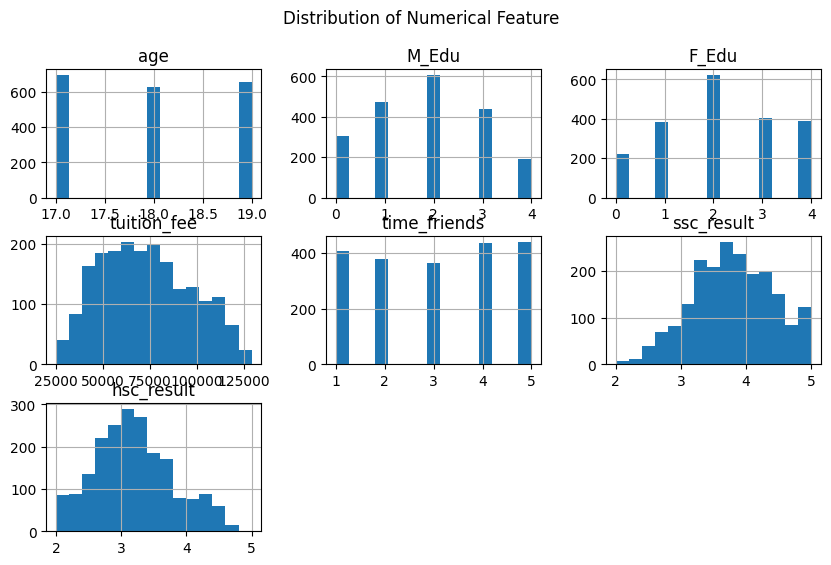

In [277]:
df.hist(bins= 15, figsize=(10,6))

plt.suptitle('Distribution of Numerical Feature')

In [278]:
numerical_cols = ['age','tuition_fee','ssc_result','hsc_result']


df[numerical_cols].corr()

,age,tuition_fee,ssc_result,hsc_result
age,1.000000,0.001015,-0.013061,-0.012592
tuition_fee,0.001015,1.000000,0.018385,0.041205
ssc_result,-0.013061,0.018385,1.000000,0.950178
hsc_result,-0.012592,0.041205,0.950178,1.000000


মেশিন লার্নিং এবং ডেটা সায়েন্সে হিটম্যাপের ব্যবহার মূলত নিচের কারণে করা হয়:

কোরিলেশন ম্যাট্রিক্স দেখতে: বিভিন্ন ফিচারের মধ্যে সম্পর্ক (Correlation) কেমন, তা বুঝতে এটি সবচেয়ে বেশি ব্যবহৃত হয়। যেমন আপনার ভিডিওর স্ক্রিনে যে হিটম্যাপটি দেখা যাচ্ছে, সেখানে গাঢ় এবং হালকা ব্লকের মাধ্যমে বিভিন্ন বিষয়ের মধ্যকার পারস্পরিক সম্পর্ককে ফুটিয়ে তোলা হয়েছে।

ডেটার ঘনত্ব বুঝতে: কোন অংশে ডেটার পরিমাণ বা ফ্রিকোয়েন্সি বেশি, তা এক নজরেই ধরা পড়ে।

ওয়েবসাইট অ্যানালিটিক্সে: একটি ওয়েবসাইটের কোন জায়গায় ভিজিটররা সবচেয়ে বেশি ক্লিক করছে বা স্ক্রোল করছে, তা ট্র্যাক করার জন্য হিটম্যাপ ব্যবহার করা হয় (বেশি ক্লিক হওয়া অংশগুলো লাল দেখায়)।

Text(0.5, 1.0, 'Correlation Heatmap of Numirical Columns')

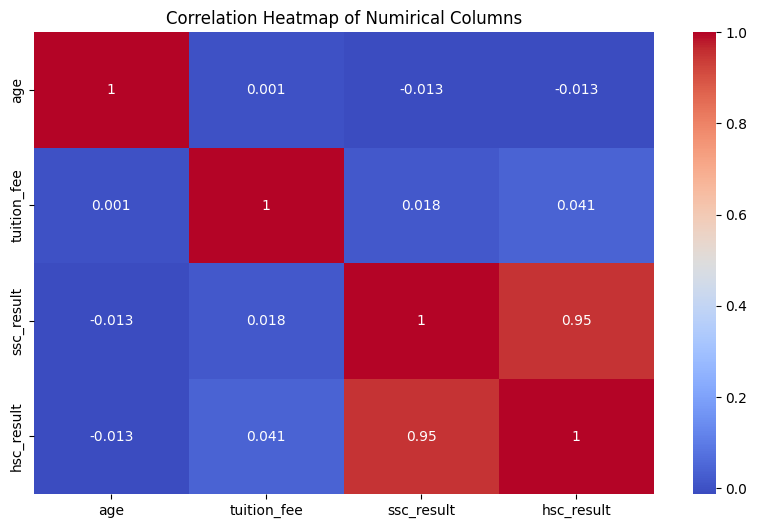

In [279]:
plt.figure(figsize=(10,6))
sns.heatmap(
    df[numerical_cols].corr(),
    annot=True,
    cmap='coolwarm')
plt.title('Correlation Heatmap of Numirical Columns')

<Axes: xlabel='tuition_fee'>

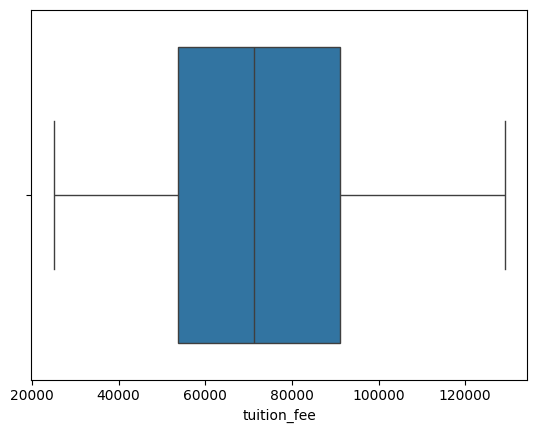

In [280]:
sns.boxplot(data = df, x = "tuition_fee")

## Preprocessing

In [281]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder,LabelEncoder,StandardScaler,MinMaxScaler
from sklearn.pipeline import Pipeline

In [282]:
# Categorize features for specific preprocessing treatments
# Nominal categories: features with no inherent mathematical order
nominal_cat = ['gender','address','famsize','Pstatus','relationship','smoker','F_Job','M_Job']

# Numerical columns: continuous values that require scaling and imputation
numerical_col = ['age','tuition_fee','ssc_result']

In [283]:
numerical_transformers = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

numerical_transformers

Pipeline(steps=[('imputer', SimpleImputer()), ('scaler', StandardScaler())])

In [284]:
nominal_transformers = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encodor', OneHotEncoder(sparse_output=False,handle_unknown='ignore'))
])

nominal_transformers

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encodor',
                 OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

In [285]:
# odinhal_transformers= Pipeline(steps=[
#     ('imputer', SimpleImputer(strategy='most_frequent')),
#     ('encodor', OrdinalEncoder(categories=[M_edu_order,F_edu_order,time_friends_order]))
# ])
# odinhal_transformers

TRain Test Split


In [286]:
preprocessor = ColumnTransformer(
    transformers=[
        ('numerical', numerical_transformers, numerical_col),
        ('nominal', nominal_transformers, nominal_cat)
    ],
    remainder="passthrough"
)
preprocessor


ColumnTransformer(remainder='passthrough',
                  transformers=[('numerical',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'tuition_fee', 'ssc_result']),
                                ('nominal',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encodor',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['gender', 'address', 'famsize', 'Pstatus',
                                  'relationship', 'smoker', 'F_Job',
                                  'M_Job'])])

In [287]:
X = df.drop(columns=['date','hsc_result'],axis=1)
y = df['hsc_result']


X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
    )

In [288]:
print(X_train)

     gender   age address famsize   Pstatus  M_Edu  F_Edu    M_Job     F_Job  \
746       M  19.0   Rural     LE3  Together      2      2    Other  Services   
1381      M  17.0   Urban     GT3  Together      0      1   Health    Farmer   
240       F  17.0   Urban     GT3  Together      4      3    Other  Services   
1646      M  18.0   Urban     LE3     Apart      2      1    Other  Business   
1460      M  18.0   Rural     GT3     Apart      4      3  At_home    Farmer   
...     ...   ...     ...     ...       ...    ...    ...      ...       ...   
1130      F  18.0   Rural     GT3  Together      2      2  At_home    Health   
1294      F  19.0   Urban     LE3  Together      2      3  At_home    Farmer   
860       F  19.0   Rural     GT3  Together      0      2   Health    Farmer   
1459      F  18.0   Rural     GT3  Together      2      4    Other  Services   
1126      M  17.0   Rural     GT3  Together      3      4      NaN  Services   

     relationship smoker  tuition_fee  

In [289]:
print(y_train)

746     4.43
1381    2.07
240     3.11
1646    2.91
1460    3.66
        ... 
1130    3.26
1294    2.72
860     4.57
1459    3.79
1126    3.07
Name: hsc_result, Length: 1614, dtype: float64


## Linear Regretion


In [290]:
from sklearn.linear_model import LinearRegression,SGDRegressor

In [291]:
lr_pipe=Pipeline(
    steps=[
        ('preprocessor',preprocessor),
        ('model' , LinearRegression())
    ]
)
lr_pipe.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'tuition_fee',
                                                   'ssc_result']),
                                                 ('nominal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encodor',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['gender', 'address',
                                                   'famsize', 'Pstatus',
                                                   'relationship', 'smoker',
                                                   'F_Job', 'M_Job'])])),
                ('model', LinearRegression())])

In [292]:
lr_pipe.predict(X_test)

array([3.22566531, 3.75147018, 3.83019613, 4.00664186, 3.90886468,
       3.33301608, 3.9843285 , 2.54037997, 1.97886626, 3.27239028,
       3.67549746, 2.91990239, 3.23829796, 4.27797546, 3.03907632,
       2.67683989, 3.71729372, 3.45240833, 2.8064922 , 2.96057683,
       2.82062305, 3.20485147, 2.99957398, 3.21864928, 1.89881831,
       2.58370593, 3.18675035, 3.82959511, 3.08845188, 3.94801852,
       2.39854271, 3.94466671, 4.31696495, 2.56460476, 3.19397834,
       3.26413536, 2.75935124, 3.65848872, 2.48692797, 2.60907848,
       3.07614707, 2.97405288, 3.73760615, 2.76965129, 2.17795697,
       3.0682365 , 2.62107646, 2.60926091, 4.03558054, 3.26099047,
       3.07457897, 3.45268988, 4.23316558, 3.63562822, 3.07047904,
       3.19897028, 3.29199946, 2.67475419, 3.81647227, 2.67135675,
       3.00589862, 2.76737407, 2.49028194, 4.43360442, 2.5597574 ,
       3.21127693, 3.96661533, 2.67087186, 3.03353973, 3.22560591,
       3.03057043, 2.72163419, 2.61374344, 3.63605177, 3.07885

In [293]:
SGD_pipe=Pipeline(
    steps=[
        ('preprocessor',preprocessor),
        ('model' , SGDRegressor())
    ]
)
SGD_pipe.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'tuition_fee',
                                                   'ssc_result']),
                                                 ('nominal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encodor',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['gender', 'address',
                                                   'famsize', 'Pstatus',
                                                   'relationship', 'smoker',
                                                   'F_Job', 'M_Job'])])),
                ('model', SGDRegressor())])

In [294]:
SGD_pipe.predict(X_test)

array([3.21301892, 3.76161294, 3.82875897, 3.93445317, 3.84384243,
       3.33776961, 3.94840075, 2.50179299, 1.96447787, 3.28376575,
       3.67091513, 2.92130005, 3.23391419, 4.27735133, 3.04788369,
       2.63543882, 3.71636051, 3.39202969, 2.81473178, 2.93078208,
       2.8153852 , 3.21241526, 2.95925767, 3.19018473, 1.90209942,
       2.50467975, 3.19920197, 3.82702326, 3.04756234, 3.95150142,
       2.40019494, 3.94639492, 4.27805571, 2.57179161, 3.20399359,
       3.2745285 , 2.7644462 , 3.66959525, 2.4921307 , 2.6044598 ,
       3.08980331, 2.98362335, 3.7355356 , 2.76839948, 2.13027427,
       3.0763939 , 2.63675971, 2.59615883, 3.98814189, 3.22824411,
       3.06231964, 3.45496971, 4.19344169, 3.61102161, 3.05572228,
       3.15865549, 3.29657654, 2.67181156, 3.81836167, 2.60012814,
       3.01837379, 2.76225154, 2.4810514 , 4.43459541, 2.56901736,
       3.21370916, 3.91773145, 2.67196816, 3.03442821, 3.19205396,
       3.02529312, 2.72886004, 2.61039797, 3.64423062, 3.07236

## Model Performance

In [295]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score,root_mean_squared_error

In [296]:
# Liner Regretion

y_pred = lr_pipe.predict(X_test)


print(f"MSE: {round(mean_squared_error(y_test, y_pred), 4)}")
print(f"R2: {round(r2_score(y_test, y_pred), 4)}")
print(f"RMSE: {round(root_mean_squared_error(y_test, y_pred), 4)}")
print(f"MAE: {round(mean_absolute_error(y_test, y_pred), 4)}")

MSE: 0.0203
R2: 0.9459
RMSE: 0.1425
MAE: 0.1114


In [297]:
# SGD Regretion

y_pred = SGD_pipe.predict(X_test)


print(f"MSE: {round(mean_squared_error(y_test, y_pred), 4)}")
print(f"R2: {round(r2_score(y_test, y_pred), 4)}")
print(f"RMSE: {round(root_mean_squared_error(y_test, y_pred), 4)}")
print(f"MAE: {round(mean_absolute_error(y_test, y_pred), 4)}")

MSE: 0.0202
R2: 0.9461
RMSE: 0.1421
MAE: 0.1113
